In [1]:
from ultralytics import YOLO

def main():
    model = YOLO("runs/segment/runs/coffe-sni-clean-1/weights/best.pt")

    results = model.predict(
        source="coffe-sni-clean-1/valid/images",
        save=True,
        conf=0.4
    )

if __name__ == "__main__":
    main()


image 1/378 c:\dhiya\coffe-sni-clean-1\valid\images\Broken_07_jpg.rf.16c4fd49ceccac938b6e4afcb7d84dd5.jpg: 640x640 1 biji_pecah, 9.5ms
image 2/378 c:\dhiya\coffe-sni-clean-1\valid\images\Broken_07_jpg.rf.17c07501b345d0785885461cabfdebbb.jpg: 640x640 1 biji_pecah, 9.1ms
image 3/378 c:\dhiya\coffe-sni-clean-1\valid\images\Broken_08_jpg.rf.5758d379c6f5c50269dfd2cf19dffe2c.jpg: 640x640 1 biji_pecah, 9.3ms
image 4/378 c:\dhiya\coffe-sni-clean-1\valid\images\Broken_08_jpg.rf.90ad569718a74d431b8762c9c3e2dd15.jpg: 640x640 1 biji_pecah, 9.0ms
image 5/378 c:\dhiya\coffe-sni-clean-1\valid\images\Broken_11_jpg.rf.76af886658d967a540c5b228c9fa1b6f.jpg: 640x640 1 biji_pecah, 9.3ms
image 6/378 c:\dhiya\coffe-sni-clean-1\valid\images\Broken_11_jpg.rf.ef3c0b3fcd44cc28c7cea3d5e046c48c.jpg: 640x640 1 biji_pecah, 10.1ms
image 7/378 c:\dhiya\coffe-sni-clean-1\valid\images\Broken_28_jpg.rf.35069e1034042305e37129e94014432f.jpg: 640x640 1 biji_pecah, 9.5ms
image 8/378 c:\dhiya\coffe-sni-clean-1\valid\images\B


image 1/1 D:\dhiya_skirpsi\model_YOLO11-seg\dataset\test\images\Shell_04_rotated_180_jpg.rf.2d8930f9f9a39ad5c9230cc27e4749b3.jpg: 640x640 1 kulit_tanduk_kecil, 72.4ms
Speed: 6.0ms preprocess, 72.4ms inference, 3.2ms postprocess per image at shape (1, 3, 640, 640)


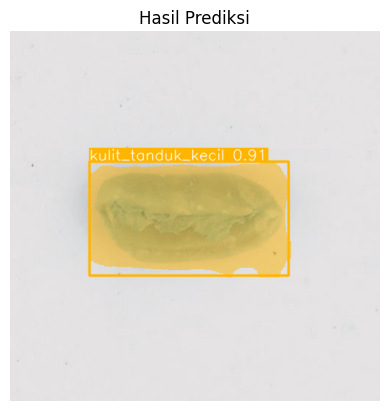

File diuji: D:/dhiya_skirpsi/model_YOLO11-seg/dataset/test/images/Shell_04_rotated_180_jpg.rf.2d8930f9f9a39ad5c9230cc27e4749b3.jpg


In [5]:
#test manual dengan ground truth
from ultralytics import YOLO
from tkinter import Tk
from tkinter.filedialog import askopenfilename
import matplotlib.pyplot as plt

def upload_and_test():
    root = Tk()
    root.withdraw()

    file_path = askopenfilename(
        title="Pilih gambar",
        filetypes=[("Image files", "*.jpg *.png *.jpeg")]
    )

    if not file_path:
        print("Tidak ada file dipilih")
        return

    model = YOLO("runs/segment/runs/coffe-sni-clean-1/weights/best.pt")

    results = model.predict(
        source=file_path,
        conf=0.4,
        save=False,
        show=True
    )

  
    # Ambil hasil pertama
    result = results[0]

    # Plot hasil (sudah ada bounding box + mask)
    img = result.plot()

    # Tampilkan di output (Jupyter / script)
    plt.imshow(img)
    plt.axis("off")
    plt.title("Hasil Prediksi")
    plt.show()

    print(f"File diuji: {file_path}")

if __name__ == "__main__":
    upload_and_test()

In [6]:
#Hitung mIoU dan Dice
import torch
import numpy as np
from ultralytics import YOLO
import cv2
import os

# ==== CONFIG ====
MODEL_PATH = "runs/segment/runs/coffe-sni-clean-1/weights/best.pt"
IMAGE_DIR = "coffe-sni-clean-1/test/images"
LABEL_DIR = "coffe-sni-clean-1/test/labels"

# ==== LOAD MODEL ====
model = YOLO(MODEL_PATH)

def polygon_to_mask(img_shape, polygons):
    """Convert YOLO polygon ke mask"""
    mask = np.zeros(img_shape[:2], dtype=np.uint8)
    for poly in polygons:
        pts = np.array(poly, dtype=np.int32)
        cv2.fillPoly(mask, [pts], 1)
    return mask

def compute_metrics(pred_mask, gt_mask):
    pred_mask = pred_mask.astype(bool)
    gt_mask = gt_mask.astype(bool)

    intersection = np.logical_and(pred_mask, gt_mask).sum()
    union = np.logical_or(pred_mask, gt_mask).sum()

    iou = intersection / union if union != 0 else 0
    dice = (2 * intersection) / (pred_mask.sum() + gt_mask.sum()) if (pred_mask.sum() + gt_mask.sum()) != 0 else 0

    return iou, dice

ious = []
dices = []

# ==== LOOP SEMUA IMAGE ====
for img_name in os.listdir(IMAGE_DIR):
    img_path = os.path.join(IMAGE_DIR, img_name)
    label_path = os.path.join(LABEL_DIR, img_name.replace(".jpg", ".txt"))

    img = cv2.imread(img_path)

    # ===== PREDICTION =====
    results = model.predict(img_path, conf=0.4, verbose=False)
    r = results[0]

    # ===== PRED MASK =====
    if r.masks is not None:
        pred_mask = r.masks.data[0].cpu().numpy()
        pred_mask = cv2.resize(pred_mask, (img.shape[1], img.shape[0]))
        pred_mask = (pred_mask > 0.5).astype(np.uint8)
    else:
        pred_mask = np.zeros(img.shape[:2], dtype=np.uint8)

    # ===== GT MASK =====
    gt_mask = np.zeros(img.shape[:2], dtype=np.uint8)

    if os.path.exists(label_path):
        with open(label_path, "r") as f:
            lines = f.readlines()

        polygons = []
        for line in lines:
            parts = list(map(float, line.strip().split()))
            coords = parts[1:]
            pts = np.array(coords).reshape(-1, 2)

            # convert normalized → pixel
            pts[:, 0] *= img.shape[1]
            pts[:, 1] *= img.shape[0]
            polygons.append(pts)

        gt_mask = polygon_to_mask(img.shape, polygons)

    # ===== METRICS =====
    iou, dice = compute_metrics(pred_mask, gt_mask)
    ious.append(iou)
    dices.append(dice)

# ==== FINAL RESULT ====
print("\n📊 HASIL AKHIR:")
print(f"Mean IoU  : {np.mean(ious):.4f}")
print(f"Mean Dice : {np.mean(dices):.4f}")


📊 HASIL AKHIR:
Mean IoU  : 0.8635
Mean Dice : 0.9115
